In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [2]:
#Health Insurance Dataset
df = pd.read_csv(r"C:\Users\Given\Downloads\Health Insurance Cleaned.csv", sep=";")

# Exploritory Data Analysis

In [3]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 82 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Personal_Code                                   16000 non-null  float64
 1   Days_Visited_Two_Hospitals                      16000 non-null  int64  
 2   Months_Visited                                  16000 non-null  int64  
 3   Max_Monthly_Visit_Days                          16000 non-null  int64  
 4   Avg_Monthly_Visit_Days                          16000 non-null  float64
 5   Max_Monthly_Hospitals_Visited                   16000 non-null  int64  
 6   Avg_Monthly_Hospitals_Visited                   16000 non-null  float64
 7   Total_Visits                                    16000 non-null  int64  
 8   Max_Monthly_Visits                              16000 non-null  int64  
 9   Avg_Monthly_Visits      

<span style="font-size:22px;">The Dataset has 82 variables, of which 81 are the predictors with n = 16 000</span>

In [4]:
display(df.head())

,Personal_Code,Days_Visited_Two_Hospitals,Months_Visited,Max_Monthly_Visit_Days,Avg_Monthly_Visit_Days,Max_Monthly_Hospitals_Visited,Avg_Monthly_Hospitals_Visited,Total_Visits,Max_Monthly_Visits,Avg_Monthly_Visits,...,Drug_Cost_Percentage,Personal_Payment_Drug_Percentage,Examination_Cost_Percentage,Personal_Payment_Examination_Percentage,Treatment_Cost_Percentage,Personal_Payment_Treatment_Percentage,Civil_Affairs_Assistance,Urban_Rural_Preferential_Support,Registered,Result
0,352120000000000.00,0,6,7,5.67,3,2.17,34,7,5.67,...,0.94,0.00,0.05,0.00,0.01,0.00,0,0,1,0
1,352120000000000.00,0,6,4,2.50,2,1.33,15,4,2.50,...,0.96,0.00,0.03,0.00,0.01,0.00,0,0,1,0
2,352120000000000.00,8,6,8,6.17,3,2.17,45,9,7.50,...,0.78,0.00,0.00,0.00,0.20,0.00,0,0,0,0
3,352120000000000.00,0,6,6,3.67,2,1.83,23,6,3.83,...,0.46,0.00,0.00,0.00,0.54,0.00,0,0,0,0
4,352120000000000.00,0,6,5,4.33,1,1.00,26,5,4.33,...,0.98,0.00,0.00,0.00,0.02,0.00,0,0,0,0


## 1. Checking for multicolinearinty amongst the covariates with a threshold of > 75%

In [5]:
corr_matrix = df.corr().abs()
high_corr_vars = [(i, j, corr_matrix.loc[i, j]) 
                  for i in corr_matrix.columns 
                  for j in corr_matrix.columns 
                  if i != j and corr_matrix.loc[i, j] > 0.75]

print("\nHighly Correlated Variables (Threshold > 0.75):")
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    print(f"{var1} - {var2}: {corr:.2f}")


Highly Correlated Variables (Threshold > 0.75):
Months_Visited - Transaction_YearMonth: 1.00
Transaction_YearMonth - Months_Visited: 1.00
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00
Total_Medical_Assistance_Hospital_Application - Total_Medical_Assistance_Individual_Share: 1.00
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00
Total_Treatment_Claim_Amount - Total_Treatment_Cost: 1.00
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00
Total_Drug_Claim_Amount - Total_Drug_Expenses: 1.00
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00
Total_Bed_Fee_Claim_Amount - Total_Bed_Fee: 1.00
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00
Total_Surgery_Claim_Amount - Total_Surgery_Cost: 1.00
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00
Total_Civil_Affairs_Assistance_Subsidy - Total_Urban_Rural_Assistance_Subsidy: 1.00
Total_All_Expenses - Total_Current_Approval_Amount: 1.00
Total_Current_Appr

## 2. Removing one variable from each highly correlated pair

In [6]:
removed_features = set()
for var1, var2, corr in sorted(high_corr_vars, key=lambda x: -x[2]):
    if var1 not in removed_features and var2 not in removed_features:
        print(f"{var1} - {var2}: {corr:.2f} (Removing {var2})")
        removed_features.add(var2)
df.drop(columns=removed_features, inplace=True)

Months_Visited - Transaction_YearMonth: 1.00 (Removing Transaction_YearMonth)
Total_Medical_Assistance_Individual_Share - Total_Medical_Assistance_Hospital_Application: 1.00 (Removing Total_Medical_Assistance_Hospital_Application)
Total_Treatment_Cost - Total_Treatment_Claim_Amount: 1.00 (Removing Total_Treatment_Claim_Amount)
Total_Drug_Expenses - Total_Drug_Claim_Amount: 1.00 (Removing Total_Drug_Claim_Amount)
Total_Bed_Fee - Total_Bed_Fee_Claim_Amount: 1.00 (Removing Total_Bed_Fee_Claim_Amount)
Total_Surgery_Cost - Total_Surgery_Claim_Amount: 1.00 (Removing Total_Surgery_Claim_Amount)
Total_Urban_Rural_Assistance_Subsidy - Total_Civil_Affairs_Assistance_Subsidy: 1.00 (Removing Total_Civil_Affairs_Assistance_Subsidy)
Total_All_Expenses - Total_Current_Approval_Amount: 1.00 (Removing Total_Current_Approval_Amount)
Total_Personal_Account_Amount - Total_Non_Account_Payment: 1.00 (Removing Total_Non_Account_Payment)
Total_Examination_Expenses - Total_Examination_Claim_Amount: 0.99 (Remov

In [7]:
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 46 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Personal_Code                              16000 non-null  float64
 1   Days_Visited_Two_Hospitals                 16000 non-null  int64  
 2   Months_Visited                             16000 non-null  int64  
 3   Max_Monthly_Visit_Days                     16000 non-null  int64  
 4   Max_Monthly_Hospitals_Visited              16000 non-null  int64  
 5   Max_Monthly_Pooled_Amount                  16000 non-null  float64
 6   Max_Monthly_Drug_Cost                      16000 non-null  float64
 7   Transaction_Year                           16000 non-null  int64  
 8   Total_Hospitalization_Days                 16000 non-null  int64  
 9   Total_Personal_Account_Amount              16000 non-null  float64
 10  Total_O

<span style="font-size:18px;">After removing variables with high multicolinearity, we now have 46 variables, of which 45 are the predictors</span>

## 3. Checking the Dataset for missing values

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Personal_Code                                 0
Days_Visited_Two_Hospitals                    0
Months_Visited                                0
Max_Monthly_Visit_Days                        0
Max_Monthly_Hospitals_Visited                 0
Max_Monthly_Pooled_Amount                     0
Max_Monthly_Drug_Cost                         0
Transaction_Year                              0
Total_Hospitalization_Days                    0
Total_Personal_Account_Amount                 0
Total_Out_Of_Pocket_Drug_Cost                 0
Total_Expensive_Drug_Cost                     0
Total_Chinese_Medicine_Cost                   0
Total_Chinese_Herbal_Medicine_Cost            0
Total_Examination_Expenses                    0
Total_Out_Of_Pocket_Examination_Cost          0
Total_Expensive_Examination_Cost              0
Total_Treatment_Cost                          0
Total_Out_Of_Pocket_Treatment_Cost            0
Total_Surgery_Cost                            0
Total_Out_Of_Pocket_Sur

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage has 24 missing values</span>

## 4. Dealing with missing Values

In [9]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
Personal_Code                                0
Days_Visited_Two_Hospitals                   0
Months_Visited                               0
Max_Monthly_Visit_Days                       0
Max_Monthly_Hospitals_Visited                0
Max_Monthly_Pooled_Amount                    0
Max_Monthly_Drug_Cost                        0
Transaction_Year                             0
Total_Hospitalization_Days                   0
Total_Personal_Account_Amount                0
Total_Out_Of_Pocket_Drug_Cost                0
Total_Expensive_Drug_Cost                    0
Total_Chinese_Medicine_Cost                  0
Total_Chinese_Herbal_Medicine_Cost           0
Total_Examination_Expenses                   0
Total_Out_Of_Pocket_Examination_Cost         0
Total_Expensive_Examination_Cost             0
Total_Treatment_Cost                         0
Total_Out_Of_Pocket_Treatment_Cost           0
Total_Surgery_Cost                           0
Total_Out_Of_Pocket_Surgery_

<span style="font-size:20px;">The variable Personal_Payment_Drug_Percentage now has 0 missing values</span>

## 5. Cheking the imbalance of the response variable 'Result'

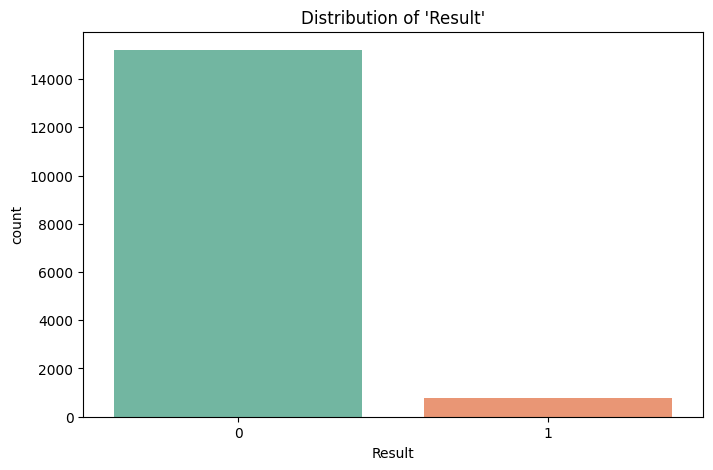

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Result', hue='Result', palette='Set2', legend=False)

plt.title("Distribution of 'Result'")
plt.show()

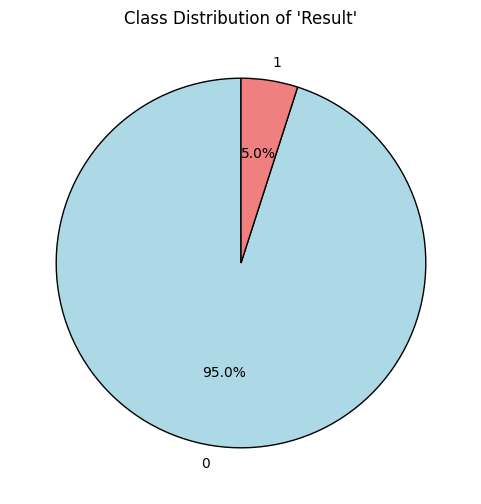


Class Counts:
Result
0    15207
1      793
Name: count, dtype: int64


In [11]:
plt.figure(figsize=(6, 6))
df['Result'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'], startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title("Class Distribution of 'Result'")
plt.ylabel("")
plt.show()

print("\nClass Counts:")
print(df['Result'].value_counts())

<span style="font-size:20px;">The target variable 'Result' is highly imbalanced</span>

## 6. Checking for outliers using Boxplots

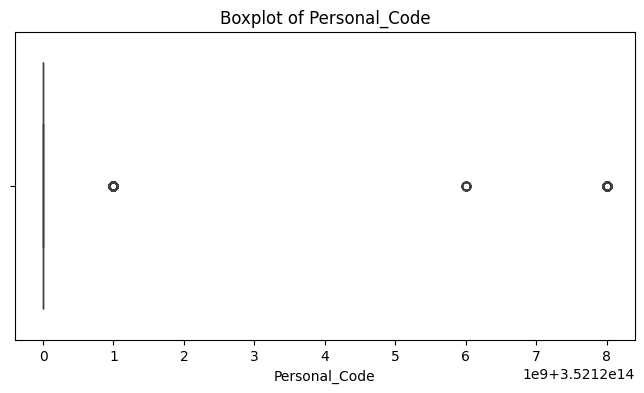

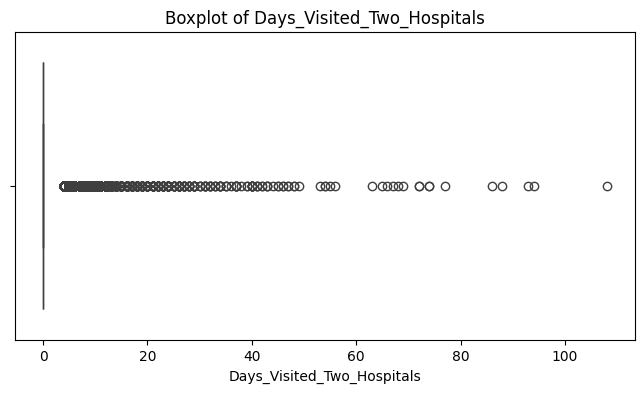

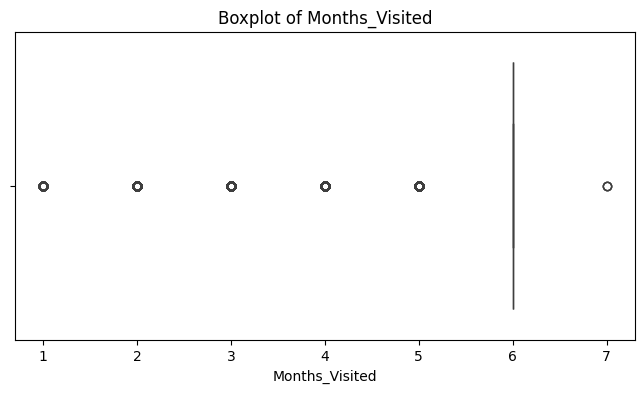

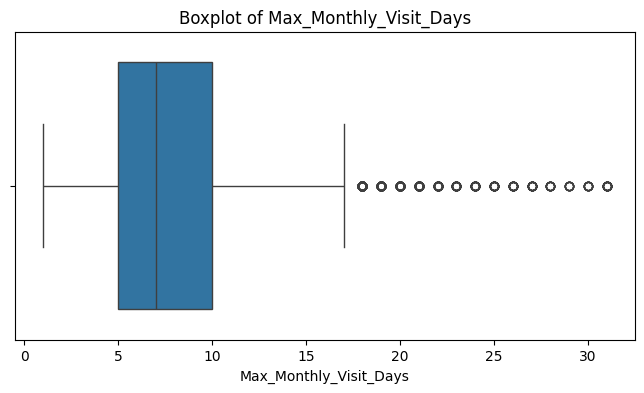

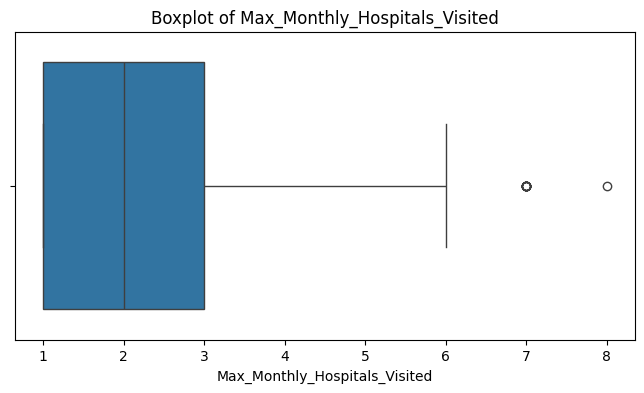

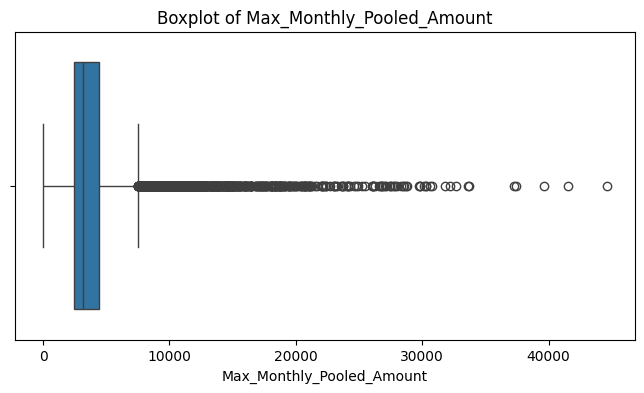

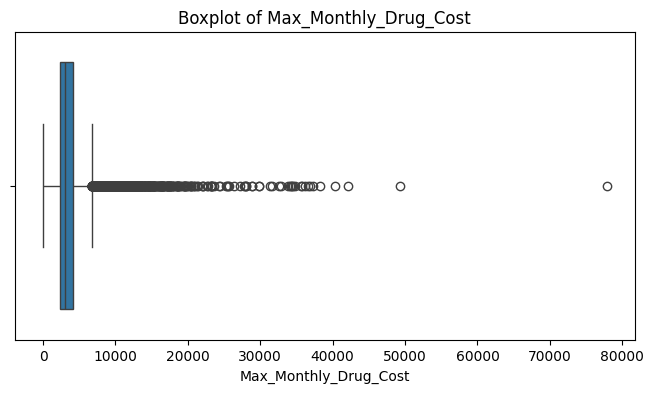

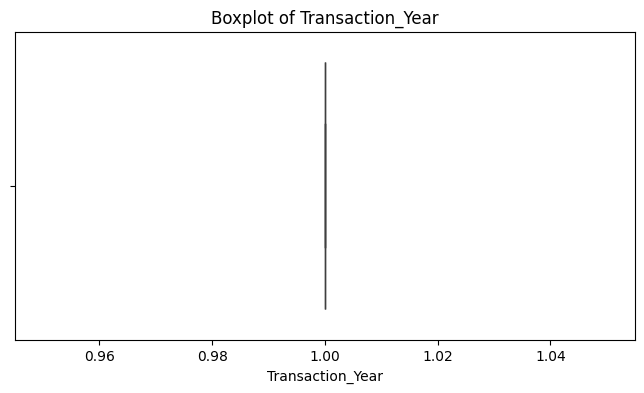

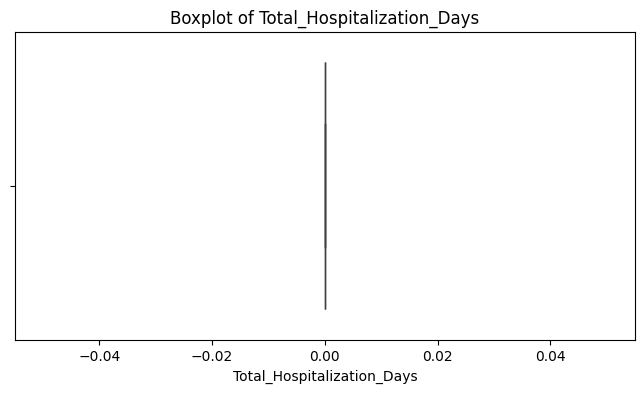

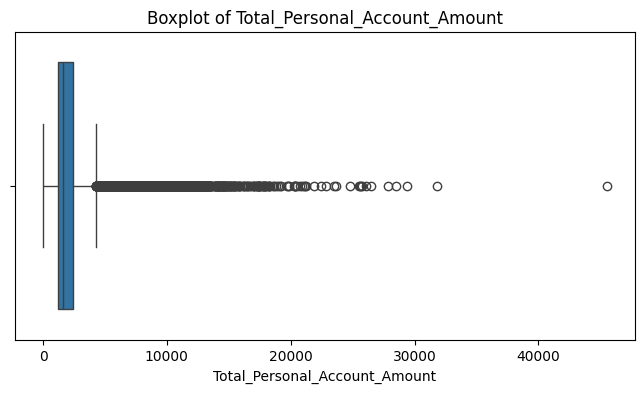

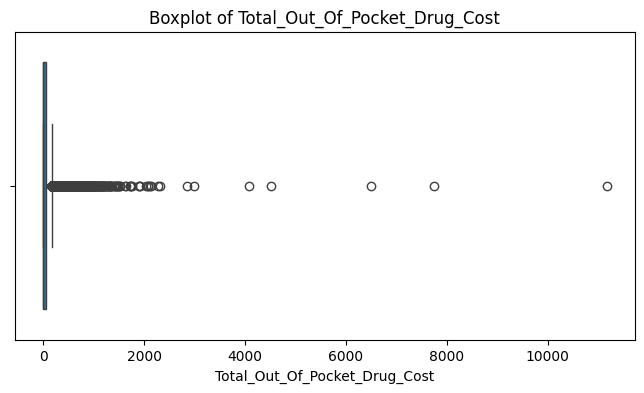

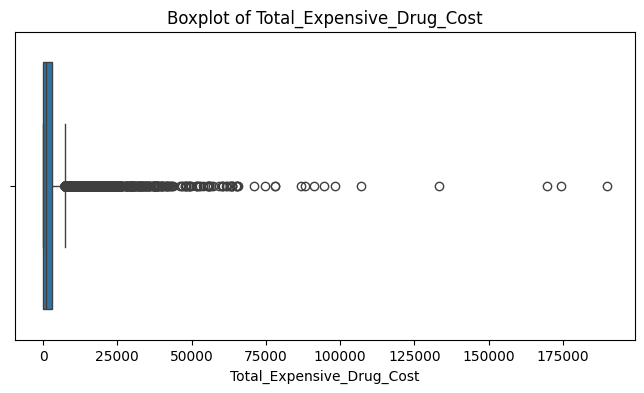

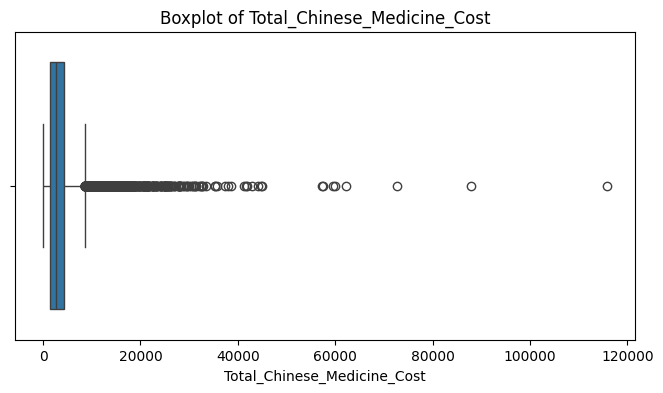

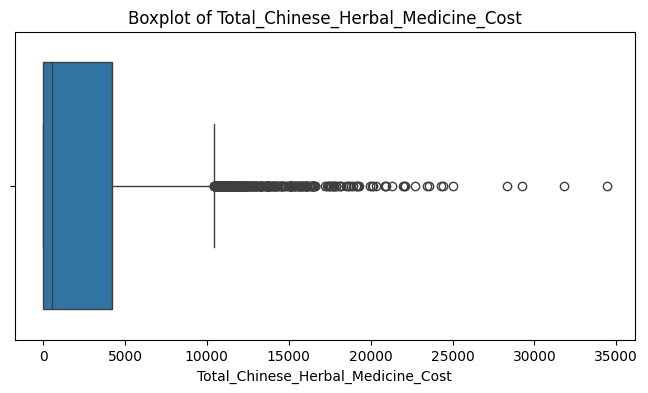

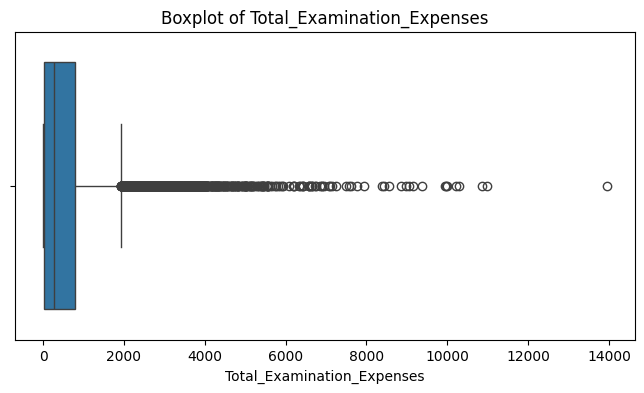

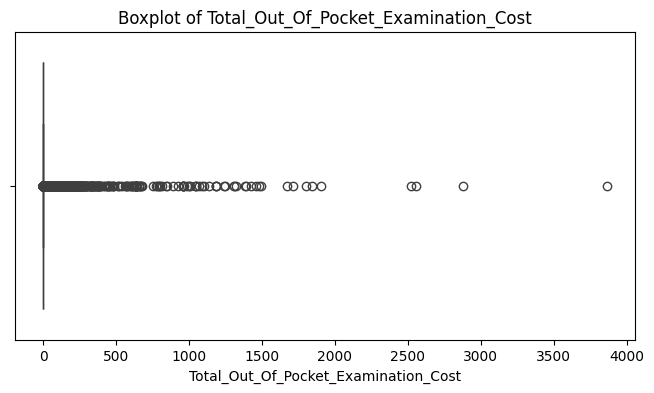

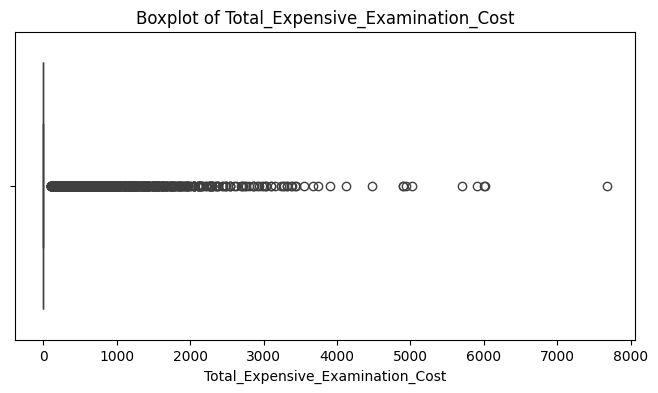

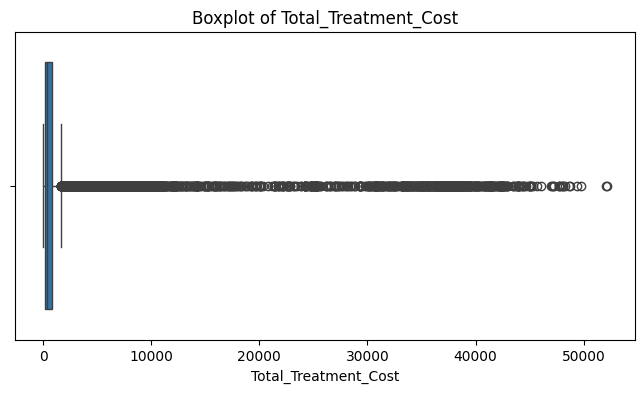

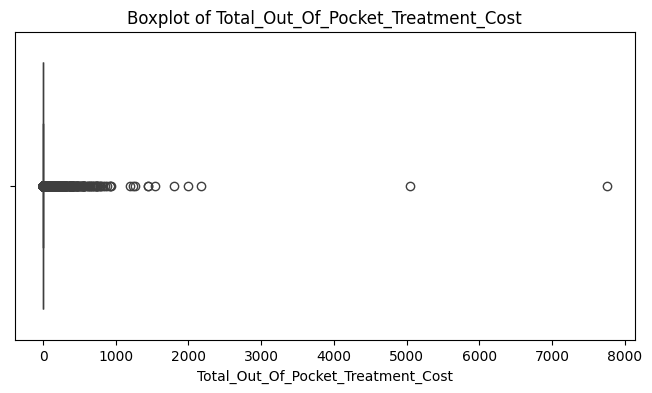

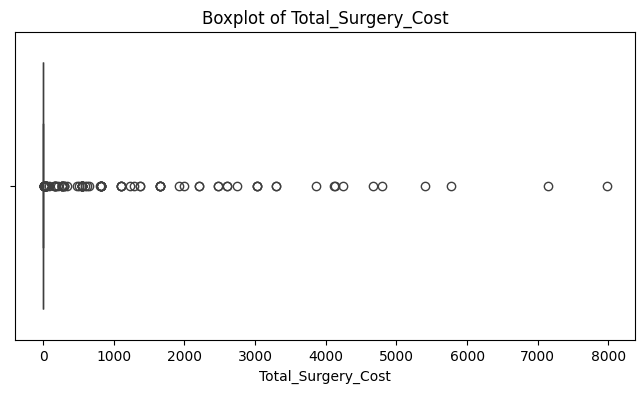

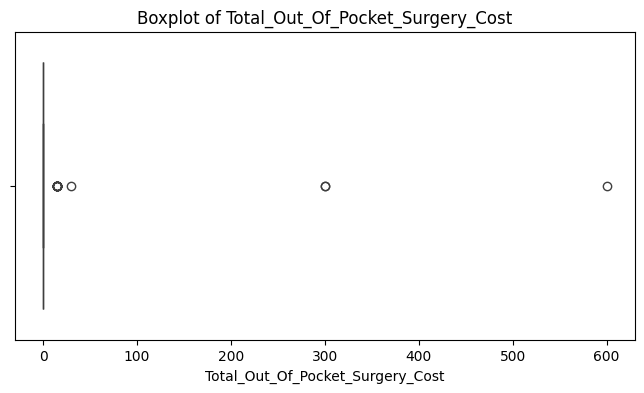

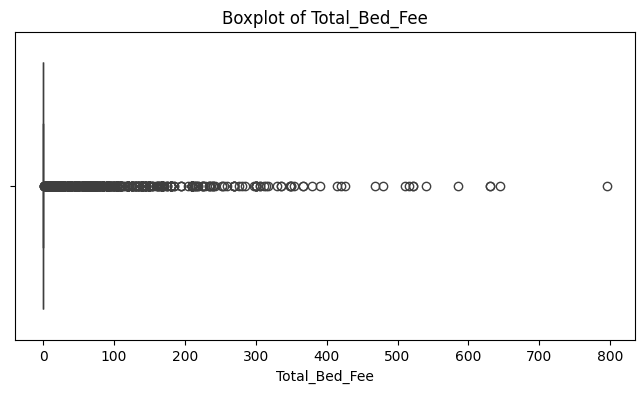

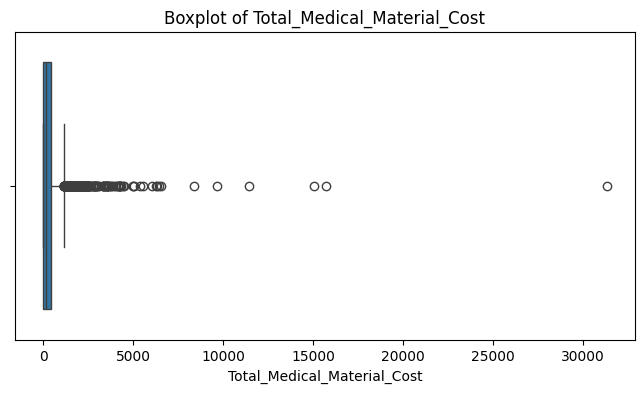

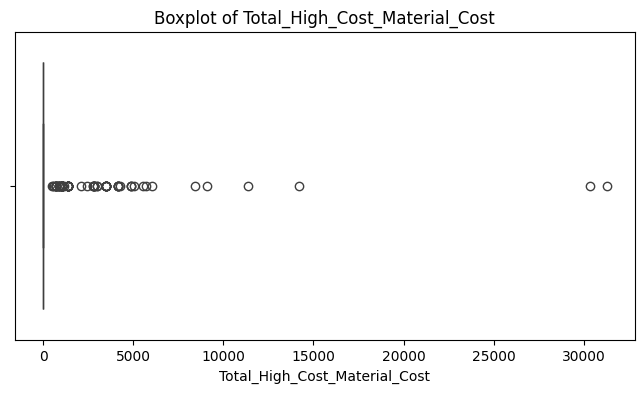

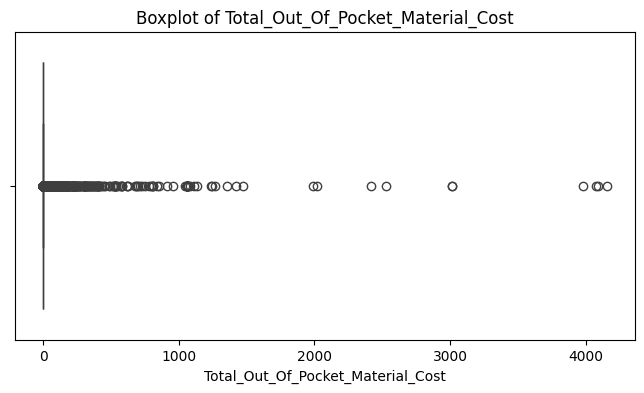

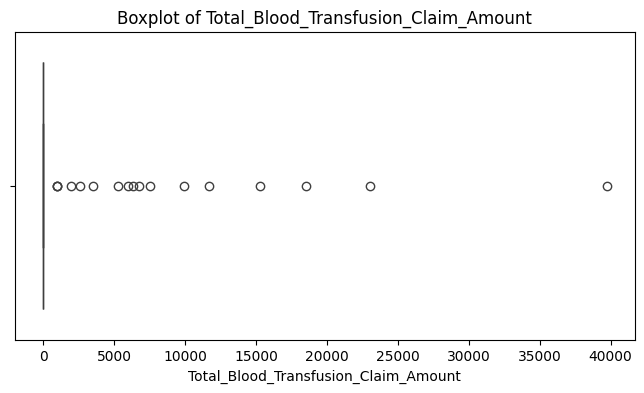

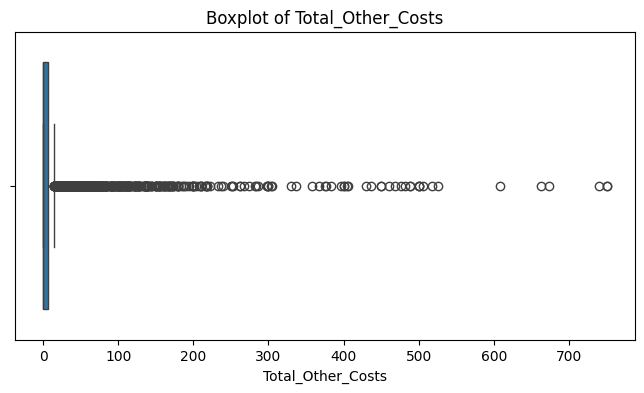

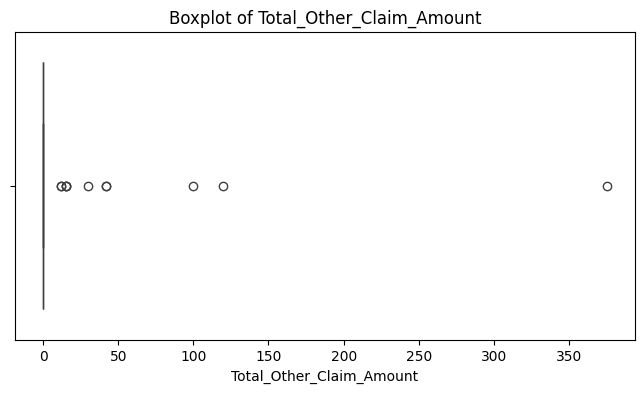

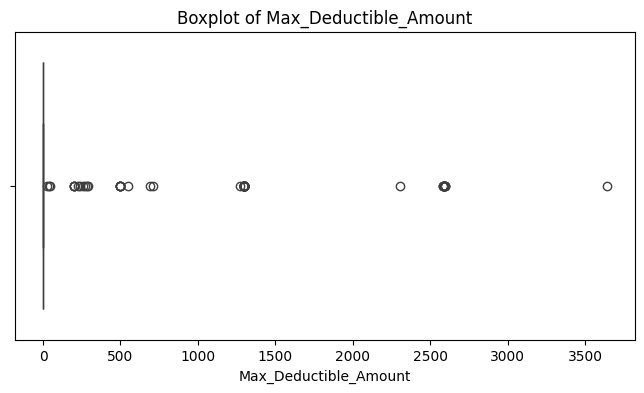

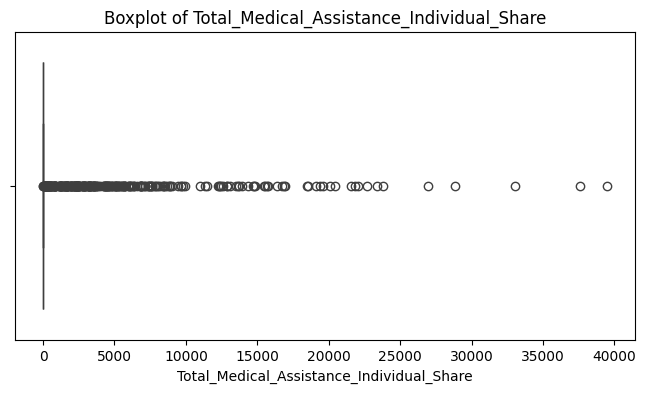

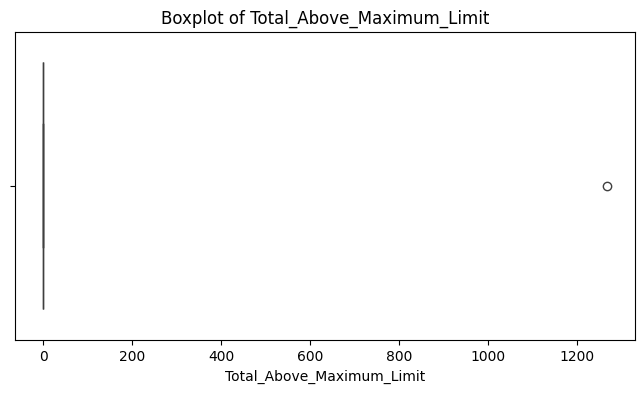

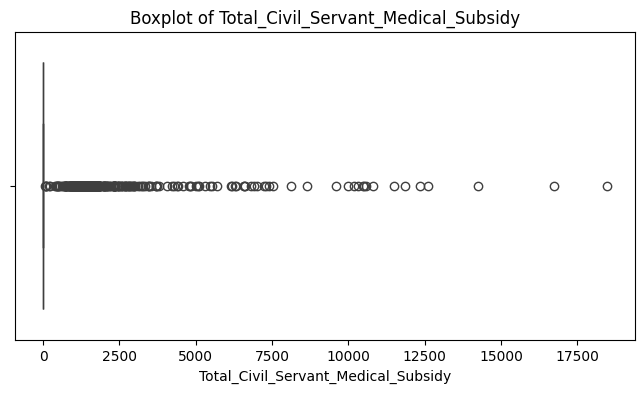

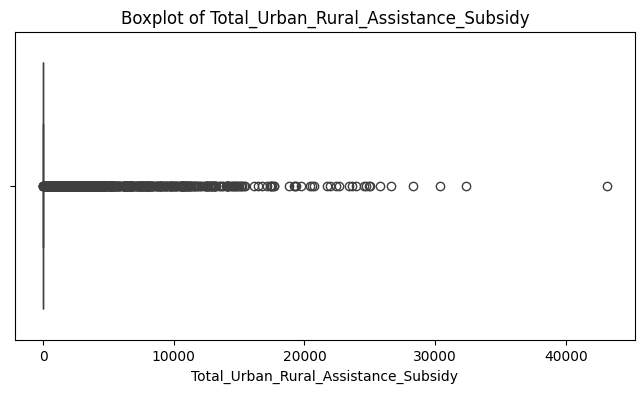

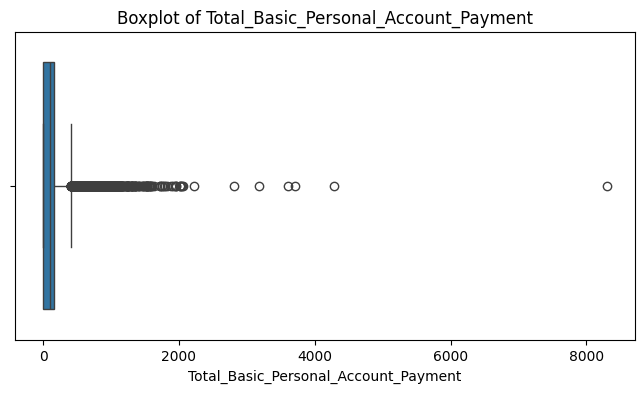

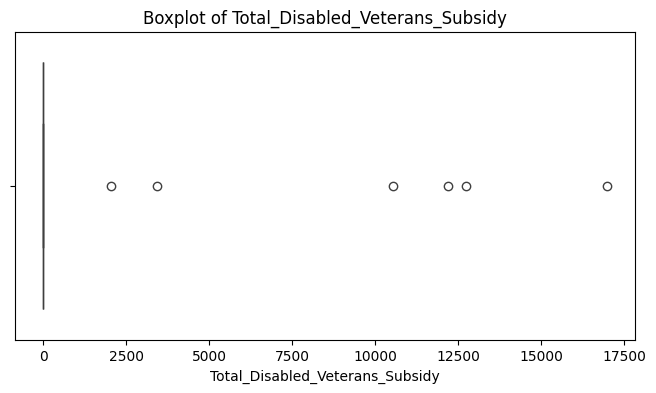

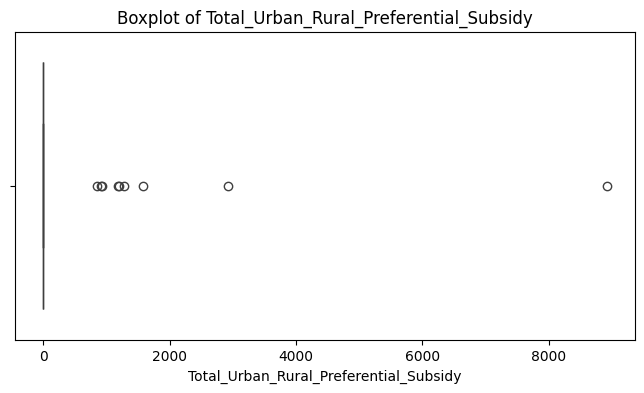

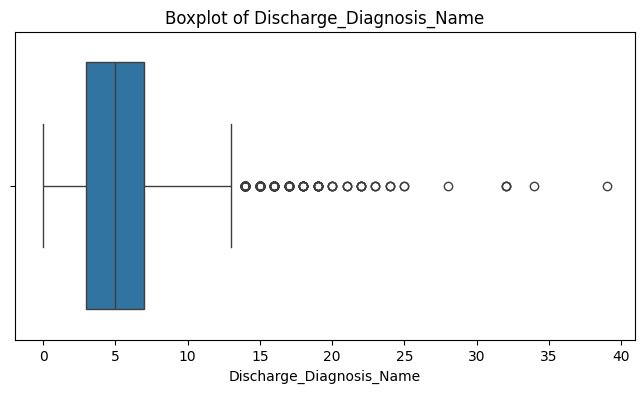

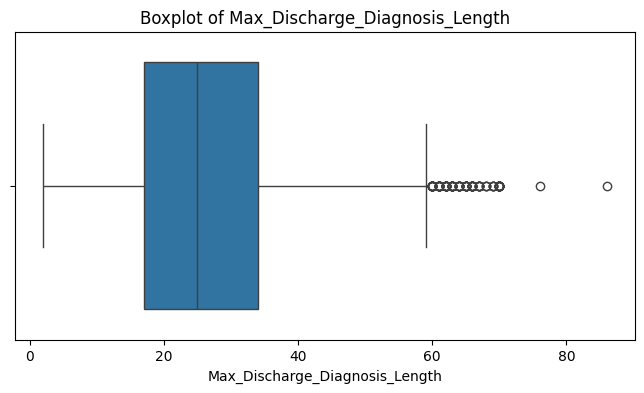

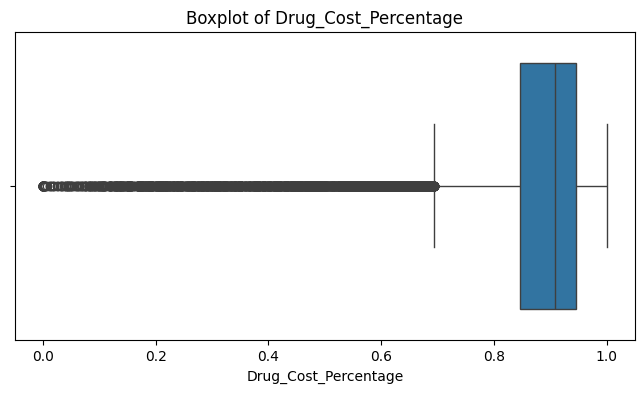

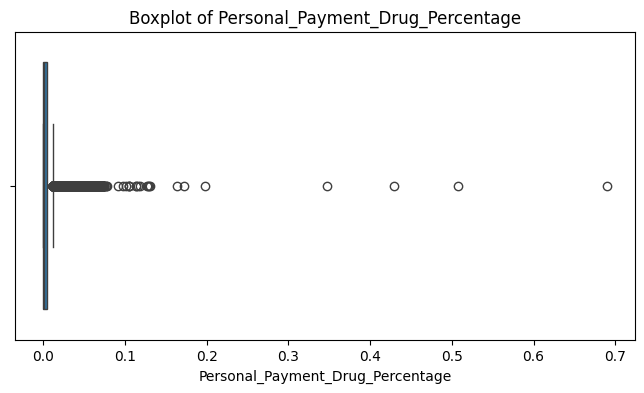

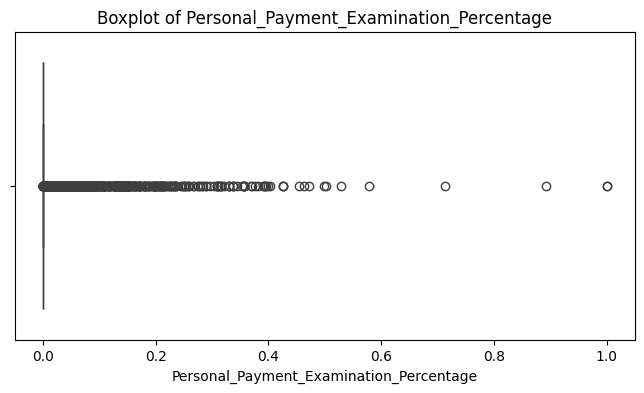

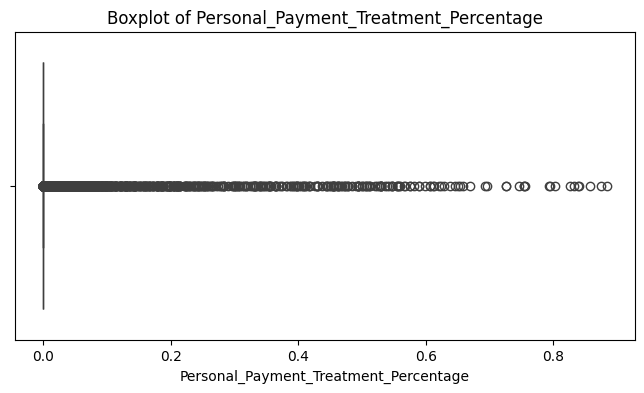

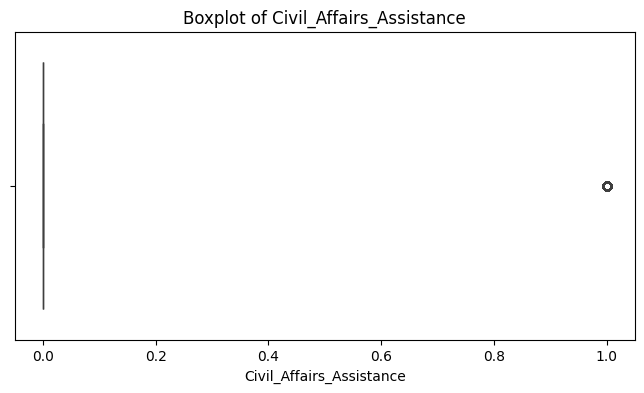

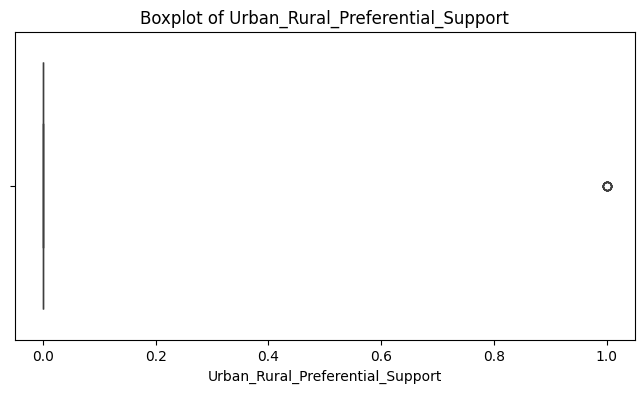

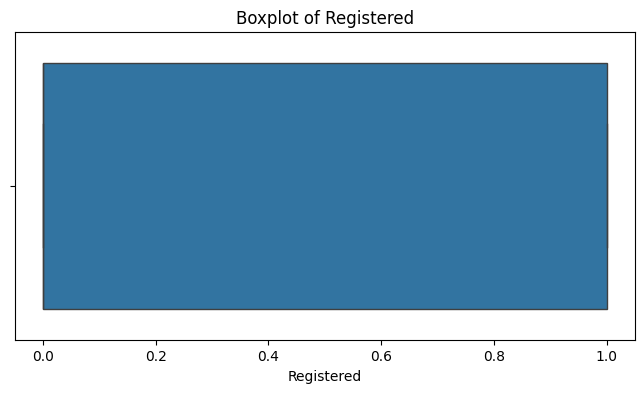

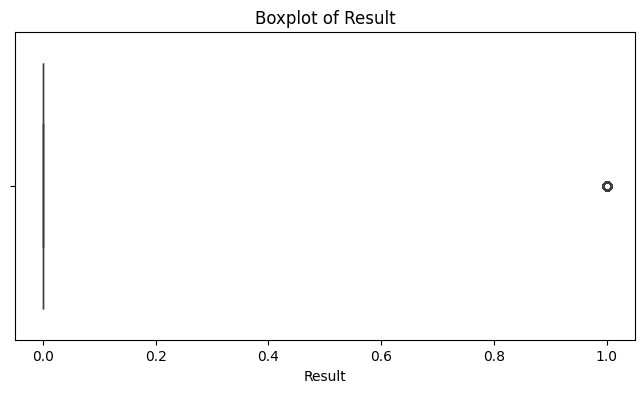

In [12]:
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

<span style="font-size:18px;">The is a presence of outliers in most of the variables</span>

# Model Picking - Lazy Predict

## 1. Process of picking the models

The Lazy Predict modelling will be executed on the Health Insurance and Credit Card Fraud datasets to consolidate the base models from both datasets. I will individually select the top 15 performing Lazy Predict models for each dataset out of the 32 offered. Consequently, I will analyze the 15 models from each set to determine the models that are commonly found in both sets. The objective is to construct ensemble stacking models using base models that both datasets share, to achieve uniformity in the base models used for modeling.

## 2. Lazy Predict

In [13]:
X, y = df.drop(columns=['Result']), df['Result']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test = StandardScaler().fit_transform(X_train), StandardScaler().fit_transform(X_test)

In [15]:
models, _ = LazyClassifier(verbose=0, ignore_warnings=True).fit(X_train, X_test, y_train, y_test)
print(models)

  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\given\anaconda3\envs\fraud_detection\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 97%|███████████████████████████████████████████████████████████████████████████████▍  | 31/32 [00:56<00:00,  1.22it/s]

[LightGBM] [Info] Number of positive: 641, number of negative: 12159
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5688
[LightGBM] [Info] Number of data points in the train set: 12800, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.050078 -> initscore=-2.942795
[LightGBM] [Info] Start training from score -2.942795


100%|██████████████████████████████████████████████████████████████████████████████████| 32/32 [00:56<00:00,  1.78s/it]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
NearestCentroid                    0.90               0.73     0.73      0.92   
DecisionTreeClassifier             0.94               0.73     0.73      0.94   
LinearDiscriminantAnalysis         0.96               0.71     0.71      0.95   
BaggingClassifier                  0.96               0.70     0.70      0.96   
Perceptron                         0.91               0.69     0.69      0.92   
XGBClassifier                      0.96               0.68     0.68      0.96   
LGBMClassifier                     0.96               0.68     0.68      0.96   
BernoulliNB                        0.57               0.67     0.67      0.69   
RandomForestClassifier             0.97               0.67     0.67      0.96   
SGDClassifier                      0.95               0.66     0.66      0.95   
ExtraTreeClassifier         

## 3. Top 15 Models from the Health Insurance Dataset

1. **NearestCentroid**  
2. **DecisionTreeClassifier**  
3. **LinearDiscriminantAnalysis**  
4. **BaggingClassifier**
5. **Perceptron**  
6. **XGBClassifier**  
7. **LGBMClassifier**
8. **BernoulliNB**  
9. **RandomForestClassifier**  
10. **SGDClassifier**  
11. **ExtraTreeClassifier**  
12. **ExtraTreesClassifier**  
13. **KNeighborsClassifier**  
14. **SVC**
15. **LabelSpreading**

## 4. List of similar models from both datasets within the Top 15

  1. **LinearDiscriminantAnalysis**  
  2. **XGBClassifier**  
  3. **NearestCentroid**  
  4. **SGDClassifier**  
  5. **ExtraTreeClassifier**  
  6. **SVC**  

# Modelling

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.svm import SVC

## 1. Linear Discriminant Analysis

In [17]:
# Initialize and train Model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [18]:
# Make predictions
y_pred_LDA = lda.predict(X_test)

In [19]:
# Evaluating the model
accuracy_LDA = accuracy_score(y_test, y_pred_LDA)
conf_matrix_LDA = confusion_matrix(y_test, y_pred_LDA)
class_report_LDA = classification_report(y_test, y_pred_LDA)

print(f'Accuracy: {accuracy_LDA:.4f}')
print('Classification Report:')
print(class_report_LDA)

Accuracy: 0.9556
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3048
           1       0.54      0.43      0.48       152

    accuracy                           0.96      3200
   macro avg       0.76      0.71      0.73      3200
weighted avg       0.95      0.96      0.95      3200



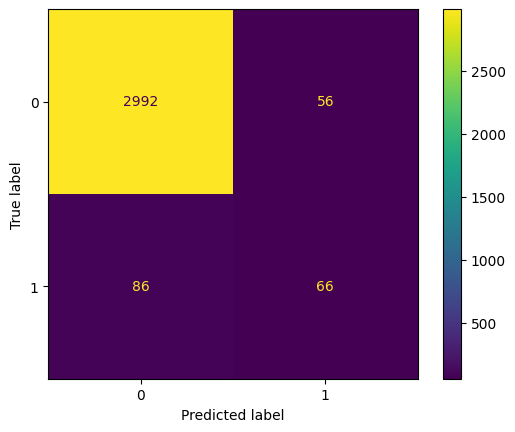

In [20]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_LDA, display_labels=lda.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5010345664365833


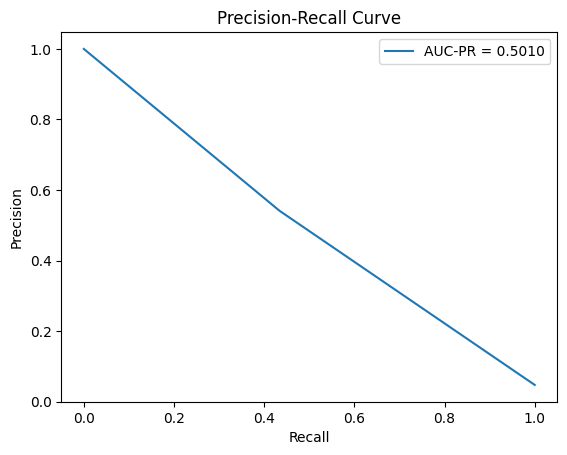

In [21]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_LDA)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 2. XGB Classifier

In [22]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [23]:
# Make Predictions
y_pred_XGB = xgb.predict(X_test)

In [24]:
# Evaluating the model
accuracy_XGB = accuracy_score(y_test, y_pred_XGB)
conf_matrix_XGB = confusion_matrix(y_test, y_pred_XGB)
class_report_XGB = classification_report(y_test, y_pred_XGB)

print(f'Accuracy: {accuracy_XGB:.4f}')
print('Classification Report:')
print(class_report_XGB)

Accuracy: 0.9650
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.78      0.37      0.50       152

    accuracy                           0.96      3200
   macro avg       0.87      0.68      0.74      3200
weighted avg       0.96      0.96      0.96      3200



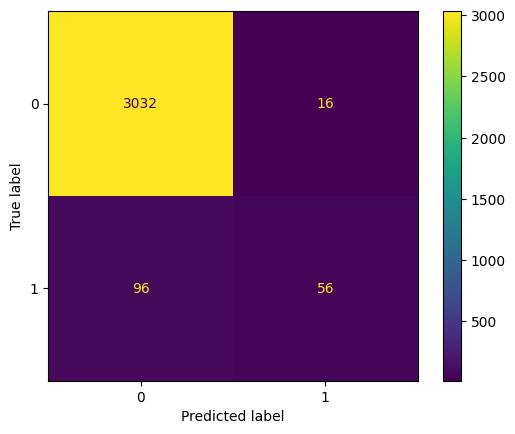

In [25]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_XGB, display_labels=xgb.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5880994152046783


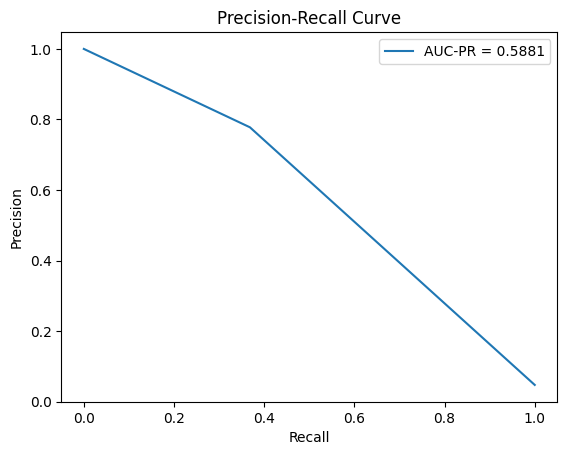

In [26]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_XGB)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 3. Nearest Centroid

In [27]:
# Initialze and Train
nc = NearestCentroid()
nc.fit(X_train, y_train)

NearestCentroid()

In [28]:
# Make Predictions
y_pred_NC = nc.predict(X_test)

In [29]:
# Evaluating the model
accuracy_NC = accuracy_score(y_test, y_pred_NC)
conf_matrix_NC = confusion_matrix(y_test, y_pred_NC)
class_report_NC = classification_report(y_test, y_pred_NC)

print(f'Accuracy: {accuracy_NC:.4f}')
print('Classification Report:')
print(class_report_NC)

Accuracy: 0.8984
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.94      3048
           1       0.25      0.55      0.34       152

    accuracy                           0.90      3200
   macro avg       0.61      0.73      0.64      3200
weighted avg       0.94      0.90      0.92      3200



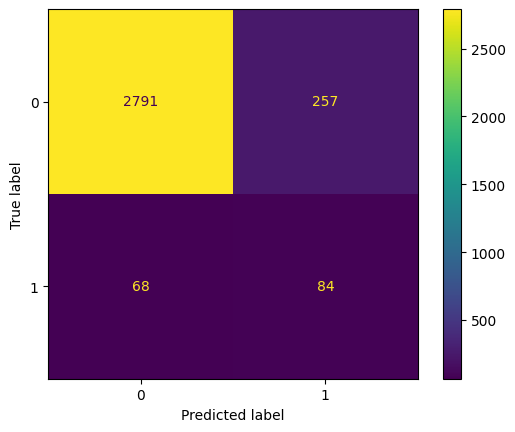

In [30]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_NC, display_labels=nc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.4101079448989041


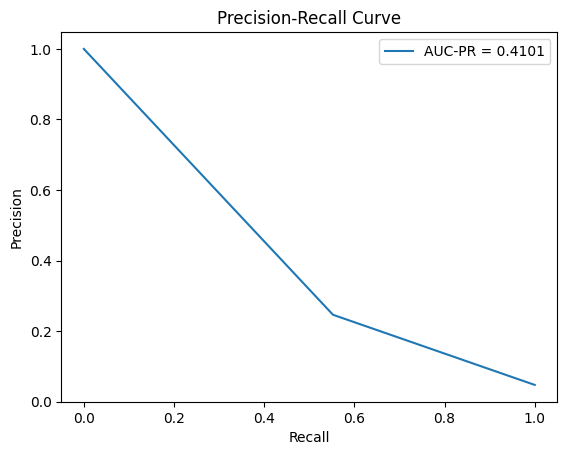

In [31]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_NC)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 4. SGD Classifier

In [32]:
# Initialize and Train Model
sgd = SGDClassifier(loss="log_loss", random_state=42) 
sgd.fit(X_train, y_train)

SGDClassifier(loss='log_loss', random_state=42)

In [33]:
# Make predictions
y_pred_SGD = sgd.predict(X_test)

In [34]:
# Evaluating the model
accuracy_SGD = accuracy_score(y_test, y_pred_SGD)
conf_matrix_SGD = confusion_matrix(y_test, y_pred_SGD)
class_report_SGD = classification_report(y_test, y_pred_SGD)

print(f'Accuracy: {accuracy_SGD:.4f}')
print('Classification Report:')
print(class_report_SGD)

Accuracy: 0.9591
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.62      0.35      0.45       152

    accuracy                           0.96      3200
   macro avg       0.80      0.67      0.71      3200
weighted avg       0.95      0.96      0.95      3200



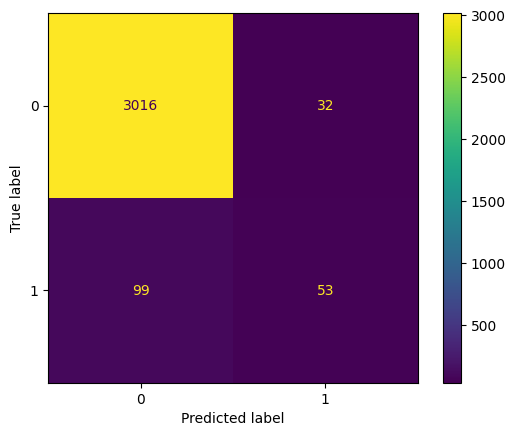

In [35]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SGD, display_labels=sgd.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5015755611455108


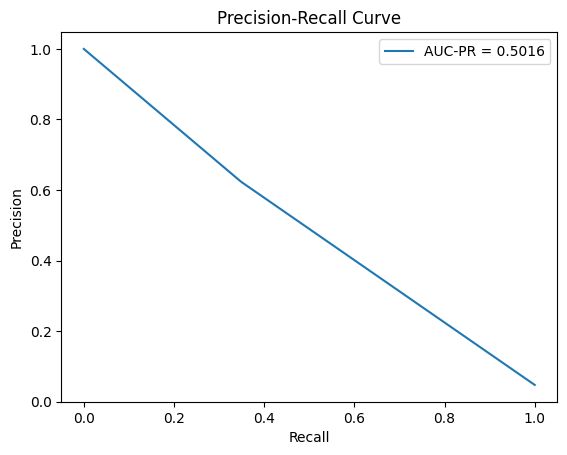

In [36]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_SGD)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 5. Extra Tree Classifier

In [37]:
# Initialize and Train Model
extra_tree = ExtraTreesClassifier(random_state=42)
extra_tree.fit(X_train, y_train)

ExtraTreesClassifier(random_state=42)

In [38]:
# Make predictions
y_pred_ET = extra_tree.predict(X_test)

In [39]:
# Evaluating the model
accuracy_ET = accuracy_score(y_test, y_pred_ET)
conf_matrix_ET = confusion_matrix(y_test, y_pred_ET)
class_report_ET = classification_report(y_test, y_pred_ET)

print(f'Accuracy: {accuracy_ET:.4f}')
print('Classification Report:')
print(class_report_ET)

Accuracy: 0.9647
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.84      0.32      0.46       152

    accuracy                           0.96      3200
   macro avg       0.90      0.66      0.72      3200
weighted avg       0.96      0.96      0.96      3200



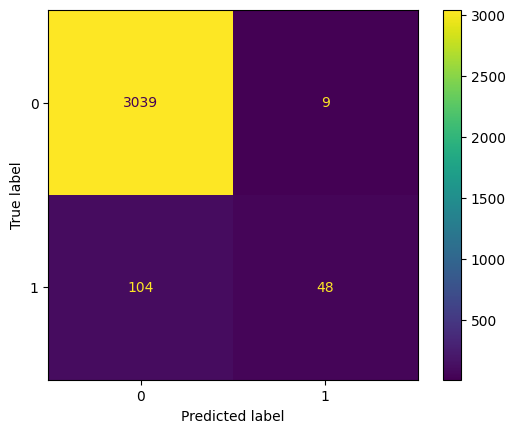

In [40]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_ET, display_labels=extra_tree.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5951973684210526


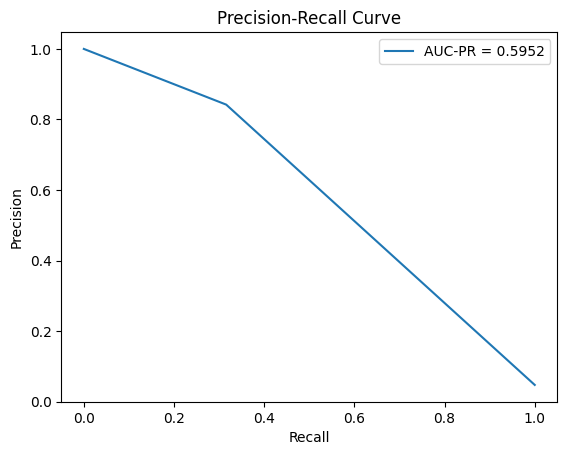

In [41]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_ET)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 6. Support Vector Classifier

In [42]:
# Initialize and Train Model
svc = SVC(kernel='rbf', probability=True, random_state=42)  
svc.fit(X_train, y_train)

SVC(probability=True, random_state=42)

In [43]:
# Make predictions
y_pred_SVC = svc.predict(X_test)

In [44]:
# Evaluating the model
accuracy_SVC = accuracy_score(y_test, y_pred_SVC)
conf_matrix_SVC = confusion_matrix(y_test, y_pred_SVC)
class_report_SVC = classification_report(y_test, y_pred_SVC)

print(f'Accuracy: {accuracy_SVC:.4f}')
print('Classification Report:')
print(class_report_SVC)

Accuracy: 0.9634
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.86      0.28      0.42       152

    accuracy                           0.96      3200
   macro avg       0.91      0.64      0.70      3200
weighted avg       0.96      0.96      0.95      3200



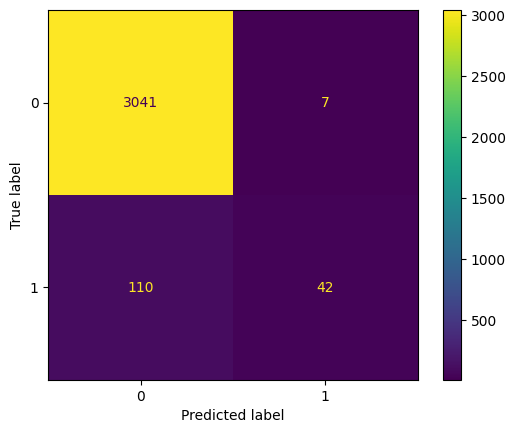

In [45]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_SVC, display_labels=svc.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5180860036710254


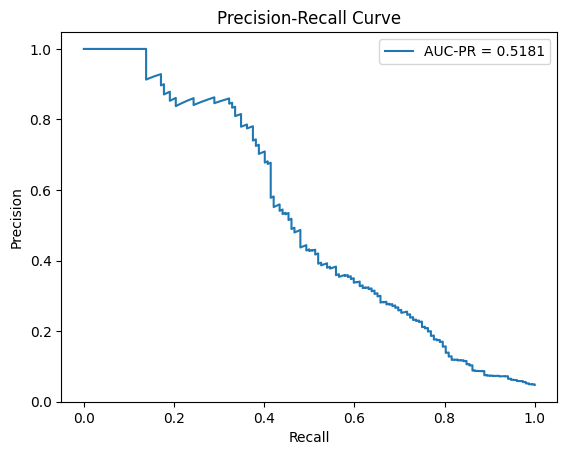

In [46]:
# AUC-PR
y_scores_SVC = svc.decision_function(X_test)
precision, recall, _ = precision_recall_curve(y_test, y_scores_SVC)
auc_pr = auc(recall, precision)
print("AUC-PR:", auc_pr)

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Stacking Ensemble Model

In [47]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [48]:
# Base models
base_models = [
    ('lda', LinearDiscriminantAnalysis()),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('nc', NearestCentroid()),
    ('sgd', SGDClassifier(loss='log_loss', random_state=42)),
    ('etc', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [49]:
# Meta-learner
meta_learner = LogisticRegression()

In [50]:
# Stacking Classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_learner, cv=5)

In [51]:
# Train model
stacking_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('lda', LinearDiscriminantAnalysis()),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None, gamma=None,
                                              grow_policy=None,
                                              importance_t...
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=None, ...)),
                               ('nc', NearestCentroid()),
                               ('sgd',
                                SGDClassifier(loss='log_loss',
                                              random_state=42)),
                               ('etc', ExtraTreesClassifier(random_state=42)),
                               ('svc', SVC(probability=True, random_state=42))],
                   final_estimator=LogisticRegression())

In [52]:
# Make predictions
y_pred_stack = stacking_model.predict(X_test)

In [53]:
# Evaluate model
accuracy_stack = accuracy_score(y_test, y_pred_stack)
class_report_stack = classification_report(y_test, y_pred_stack)

print(f'Stacking Ensemble Accuracy: {accuracy_stack:.4f}')
print('Classification Report:')
print(class_report_stack)

Stacking Ensemble Accuracy: 0.9650
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3048
           1       0.79      0.36      0.50       152

    accuracy                           0.96      3200
   macro avg       0.88      0.68      0.74      3200
weighted avg       0.96      0.96      0.96      3200



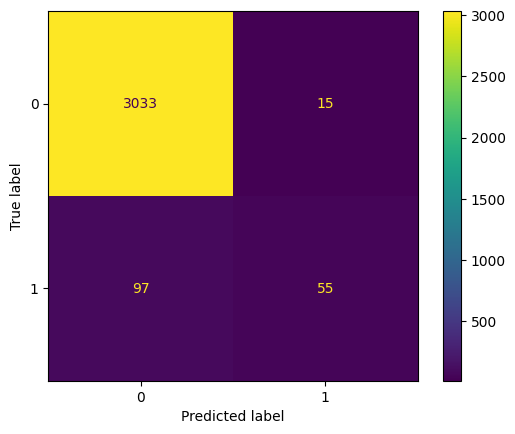

In [54]:
# Confusion Matrix
conf_matrix_stack = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_stack, display_labels=stacking_model.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5889


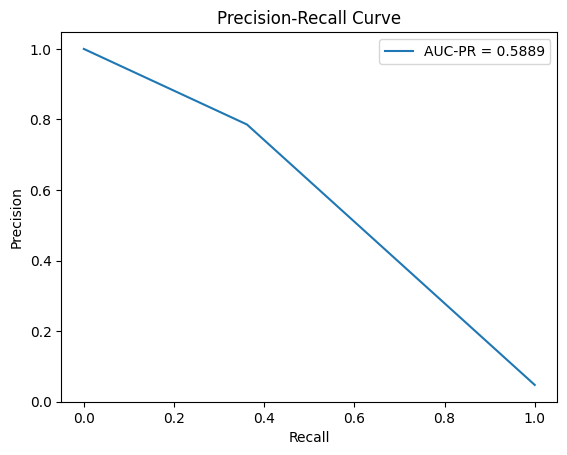

In [55]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_stack)
auc_pr = auc(recall, precision)
print(f"AUC-PR: {auc_pr:.4f}")

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# Voting Ensemble Model

In [56]:
from sklearn.ensemble import VotingClassifier

In [57]:
voting_model = VotingClassifier(estimators=base_models, voting='soft')

In [58]:
# Train Model
voting_model.fit(X_train, y_train)

VotingClassifier(estimators=[('lda', LinearDiscriminantAnalysis()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=Non...
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('nc', NearestCentroid()),
                             ('sgd',
                              SGDClassifier(loss='log_loss', random_state=42)),
                             ('etc', ExtraTreesClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

In [59]:
# Make predictions
y_pred_vote = voting_model.predict(X_test)

In [60]:
# Evaluate model
accuracy_vote = accuracy_score(y_test, y_pred_vote)
class_report_vote = classification_report(y_test, y_pred_vote)

print(f'Voting Ensemble Accuracy: {accuracy_vote:.4f}')
print('Classification Report:')
print(class_report_vote)

Voting Ensemble Accuracy: 0.9622
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3048
           1       0.67      0.39      0.50       152

    accuracy                           0.96      3200
   macro avg       0.82      0.69      0.74      3200
weighted avg       0.96      0.96      0.96      3200



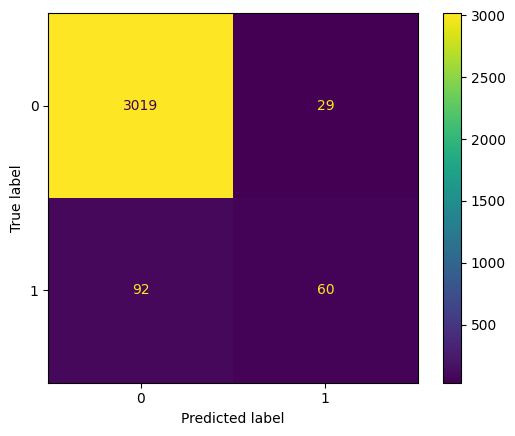

In [61]:
# Confusion matrix
conf_matrix_vote = confusion_matrix(y_test, y_pred_vote)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_vote, display_labels=voting_model.classes_)
disp.plot()
plt.show()

AUC-PR: 0.5488


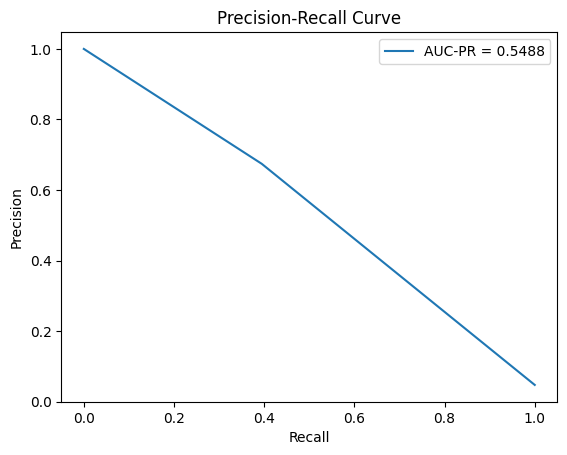

In [62]:
# AUC-PR
precision, recall, _ = precision_recall_curve(y_test, y_pred_vote)
auc_pr = auc(recall, precision)
print(f"AUC-PR: {auc_pr:.4f}")

plt.plot(recall, precision, label=f'AUC-PR = {auc_pr:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# SHAP for Explainability - Stacking Ensemble

In [63]:
import shap

In [64]:
# Extract meta-learner
meta_learner = stacking_model.final_estimator_

In [65]:
# Get transformed features
X_test_meta = stacking_model.transform(X_test)

In [66]:
# Feature Names
base_model_names = [name for name, _ in base_models]
feature_names = []

for model_name in base_model_names:
    feature_names.append(f"{model_name}_prediction")

In [67]:
# DataFrame with proper feature names
X_test_meta_df = pd.DataFrame(X_test_meta, columns=feature_names)

In [68]:
# SHAP explainer for meta-learner
explainer = shap.Explainer(meta_learner, X_test_meta_df)
shap_values = explainer(X_test_meta_df)

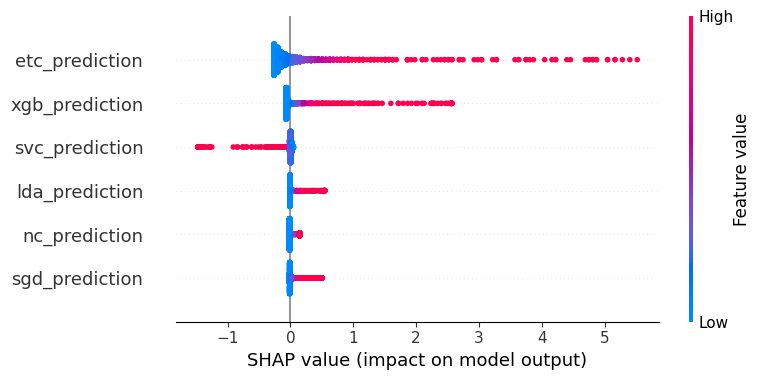

In [69]:
# Subsample for plotting (200 random samples)
sample_indices = np.random.choice(len(X_test_meta_df), size=2000, replace=False)
shap_values_sampled = shap_values[sample_indices]
X_test_meta_sampled = X_test_meta_df.iloc[sample_indices]

shap.summary_plot(shap_values_sampled, X_test_meta_sampled)

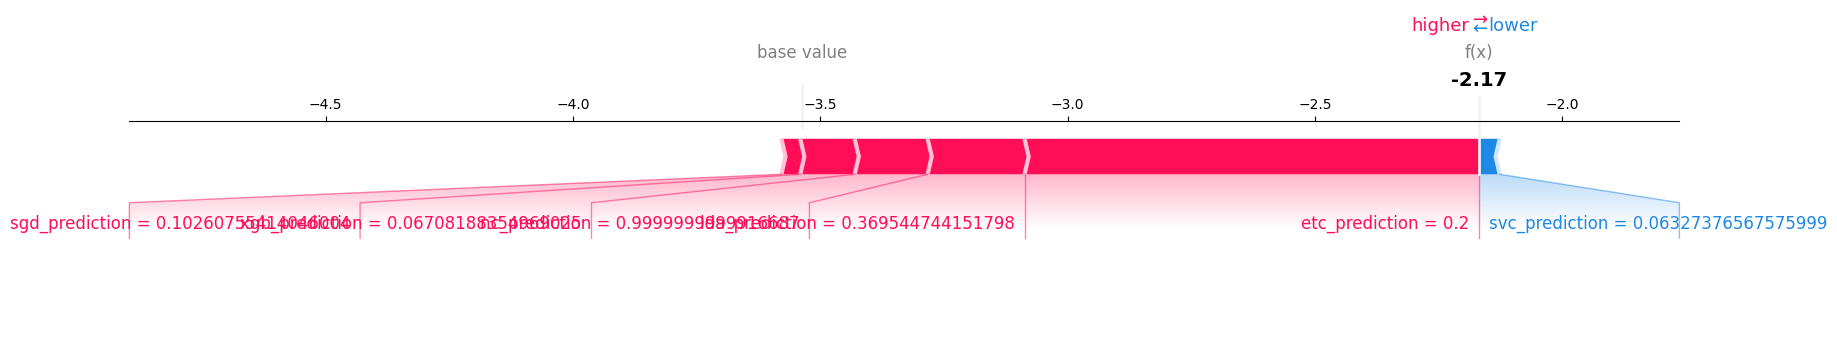

In [70]:
# Force Plot for a single prediction
idx = np.random.randint(len(X_test_meta_sampled))
shap.force_plot(explainer.expected_value, shap_values_sampled[idx].values, X_test_meta_sampled.iloc[idx], matplotlib=True)

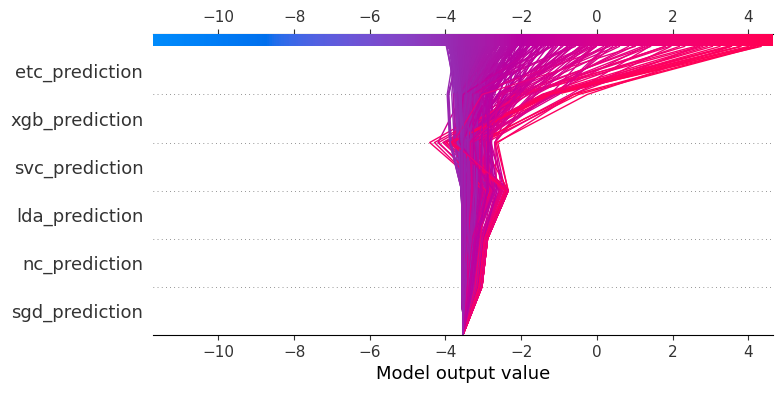

In [71]:
# Decision Plot
shap.decision_plot(explainer.expected_value, shap_values_sampled.values, X_test_meta_sampled)
plt.show()

# Model Performance Summary

| **Model**                 | **Accuracy** | **Precision (Class 1)** | **Recall (Class 1)** | **F1-Score (Class 1)** | **AUC-PR** |
|---------------------------|-------------|-------------------------|----------------------|-----------------------|------------|
| **Linear Discriminant Analysis (LDA)** | 0.9556      | 0.54                    | 0.43                 | 0.48                  | 0.5010     |
| **XGB Classifier**        | **0.9650**      | 0.78                    | 0.37                 | **0.50**                  | 0.5881     |
| **Nearest Centroid (NC)** | 0.8984      | 0.25                    | **0.55**                 | 0.34                  | 0.4101     |
| **SGD Classifier**        | 0.9591      | 0.62                    | 0.35                 | 0.45                  | 0.5016     |
| **Extra Tree Classifier (ETC)** | 0.9647  | 0.84                    | 0.32                 | 0.46                  | **0.5952** |
| **Support Vector Classifier (SVC)** | 0.9634 | **0.86**               | 0.28                 | 0.42                  | 0.5181     |
| **Stacking Ensemble**     | **0.9650**      | 0.79                    | 0.36                 | **0.50**                  | 0.5889     |
| **Voting Ensemble**       | 0.9622      | 0.67                    | 0.39             | **0.50**               | 0.5488     |

### **Observations:**
The Stacking Ensemble model is one of the most reliable models overall and achieves a high accuracy of 96.50%. It has an AUC-PR of 0.5889 which demonstrates decent handling of imbalance. The XGBoost and Extra Tree Classifier follow in accuracy with 96.50% (similar to the stacking ensemble) and 96.47%, respectively. They also show good performance with ETC obtaining the highest AUC-PR value of 0.5952 and XGB obtaining 0.5881. The Voting Ensemble and Support Vector Classifier models show high accuracy as well but have significant issues with recall for the minority class. The Nearest Centroid model has the lowest accuracy which was 89.84%. However, having the highest recall of 55% indicates that while it captures most of the positive cases, it also falsely labels a lot of negatives. In conclusion, the Stacking Ensemble, Extra Tree Classifier, and XGBoost stand out among the rest in the capture of all three metrics increasing their suitability as final candidates.